In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)
# Ganti 'folder_kamu/test.zip' dengan lokasi asli di Drive
!unzip -q "/content/drive/MyDrive/train.zip" -d "/content/dataset"
!unzip -q "/content/drive/MyDrive/test.zip" -d "/content/dataset"


Mounted at /content/drive


# 🛡️ Face Anti-Spoofing v4 — ConvNeXt-Small (ImageNet-22k)

## Mengapa ConvNeXt untuk Face Anti-Spoofing?

Perbedaan wajah asli vs palsu **bukan** tentang bentuk global — tapi tentang **tekstur lokal** yang subtle:
- `fake_printed` → moiré pattern, serat kertas
- `fake_screen` → pixel grid, refleksi layar
- `fake_mask` → tepi masker, tekstur silikon
- `fake_mannequin` → tekstur plastik, tidak ada mikro-gerakan

**ConvNeXt-Small** unggul karena:
| Aspek | ResNet50 | EfficientNetV2-S | **ConvNeXt-Small** |
|---|---|---|---|
| Pretrained data | ImageNet-1k | ImageNet-1k | **ImageNet-21k → 1k** |
| Texture sensitivity | Medium | Medium-High | **Very High** |
| Small dataset fit | Good | Good | **Excellent** |
| Depthwise conv | ❌ | ✅ | **✅ (7×7 kernel!)** |
| Modern normalization | BatchNorm | BatchNorm | **LayerNorm** |

**Teknik baru di v4:**
- 🆕 **EMA (Exponential Moving Average)** weights — menghaluskan update, sangat efektif dataset kecil
- 🆕 **RandAugment** via timm — augmentasi berbasis learned policy
- 🆕 **Stochastic Depth** aware training
- 🆕 **Label smoothing adaptif** per stage
- Semua fix dari v3 tetap dipertahankan

## 1. Install & Import

In [ ]:
!pip install timm --quiet

In [ ]:
import os, random, warnings, copy
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import timm
from timm.data import create_transform
from timm.data.auto_augment import rand_augment_transform

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.model_selection import train_test_split

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2. Konfigurasi

In [ ]:
# ── PATH ──────────────────────────────────────────────────────────────────────
TRAIN_DIR  = Path('dataset/train')    # ← sesuaikan
TEST_DIR   = Path('dataset/test')     # ← sesuaikan
OUTPUT_CSV = Path('submission_v4.csv')
CKPT_PATH  = Path('best_convnext_v4.pth')
CKPT_EMA   = Path('best_convnext_v4_ema.pth')

CLASS_NAMES = [
    'realperson', 'fake_printed', 'fake_screen',
    'fake_mask', 'fake_mannequin', 'fake_unknown'
]
NUM_CLASSES = len(CLASS_NAMES)
CLASS2IDX   = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX2CLASS   = {i: c for c, i in CLASS2IDX.items()}

# ── Model ──────────────────────────────────────────────────────────────────────
# Opsi model (pilih salah satu, uncomment yang diinginkan):
# 'convnext_small.fb_in22k_ft_in1k'  ← REKOMENDASI UTAMA (50M params)
# 'convnext_tiny.fb_in22k_ft_in1k'   ← lebih ringan (28M params), cocok VRAM terbatas
# 'convnext_base.fb_in22k_ft_in1k'   ← lebih powerful (89M params), butuh VRAM >8GB
BACKBONE_NAME = 'convnext_small.fb_in22k_ft_in1k'

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE   = 32
VAL_SPLIT    = 0.2
NUM_WORKERS  = 0
WEIGHT_DECAY = 5e-2    # ConvNeXt pakai WD lebih tinggi dari ResNet
PATIENCE     = 3      # per stage

# Progressive stages: (img_size, epochs, lr_head, lr_backbone, label_smooth, mix_prob)
PROG_STAGES = [
    (128, 5,  2e-3, 0.0,  0.15, 0.6),
    (192, 7,  1e-3, 8e-5, 0.10, 0.4),
    (224, 8,  5e-4, 4e-5, 0.05, 0.3),
    (256, 4,  2e-4, 2e-5, 0.02, 0.1),
]

# Unfreeze schedule ConvNeXt: punya 4 stages (0-3, dari shallow ke deep)
# Kita unfreeze dari deep ke shallow secara bertahap
# {stage_idx: jumlah stage ConvNeXt yang di-unfreeze dari belakang}
UNFREEZE_SCHEDULE = {0: 0, 1: 2, 2: 3, 3: 4}

# EMA
EMA_DECAY    = 0.9998  # makin tinggi = makin smooth

# Mixup / CutMix
MIXUP_ALPHA  = 0.4
CUTMIX_ALPHA = 1.0

print(f'Backbone : {BACKBONE_NAME}')
print(f'Stages   : {[(s,e) for s,e,*_ in PROG_STAGES]}')

Backbone : convnext_small.fb_in22k_ft_in1k
Stages   : [(128, 5), (192, 7), (224, 8), (256, 4)]


## 3. EMA — Exponential Moving Average Weights

In [ ]:
class ModelEMA:
    """
    Exponential Moving Average of model weights.

    Ide: daripada pakai weight terakhir untuk inference,
    pakai rata-rata bergerak exponensial dari semua weight selama training.
    Hasilnya lebih smooth dan generalizes lebih baik — sangat efektif
    untuk dataset kecil karena mengurangi sensitivitas terhadap
    update tunggal yang noisy.

    shadow_weight = decay * shadow_weight + (1 - decay) * current_weight
    """
    def __init__(self, model, decay=EMA_DECAY):
        self.decay  = decay
        self.shadow = {}
        self.backup = {}
        # Simpan copy dari semua parameter
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone().float()

    @torch.no_grad()
    def update(self, model):
        """Panggil setelah setiap optimizer step."""
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.shadow:
                new_avg = (1.0 - self.decay) * param.data.float() \
                          + self.decay * self.shadow[name]
                self.shadow[name] = new_avg

    def apply_shadow(self, model):
        """Ganti weight model dengan EMA weight (untuk evaluasi/inference)."""
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.shadow:
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])

    def restore(self, model):
        """Kembalikan ke weight training original."""
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.backup:
                param.data.copy_(self.backup[name])
        self.backup = {}

    def state_dict(self): return self.shadow
    def load_state_dict(self, sd): self.shadow = sd


print('✅ EMA ready')

✅ EMA ready


## 4. Augmentasi — RandAugment + Manual

In [ ]:
def get_train_transform(img_size):
    """
    Gabungan RandAugment (timm) + augmentasi manual.
    RandAugment memilih 2 dari ~30 operasi augmentasi secara acak per image
    dengan magnitude yang juga diacak — lebih powerful dari fixed pipeline.
    """
    # RandAugment config: magnitude=9, num_ops=2 (standar untuk supervised)
    ra_params = {
        'translate_const': int(img_size * 0.1),
        'img_mean': tuple([int(x*255) for x in [0.485, 0.456, 0.406]]),
    }
    rand_aug = rand_augment_transform(
        config_str='rand-m9-mstd0.5-inc1',
        hparams=ra_params
    )

    return T.Compose([
        # Geometri dasar
        T.Resize((int(img_size * 1.15), int(img_size * 1.15))),
        T.RandomCrop(img_size),
        T.RandomHorizontalFlip(p=0.5),

        # RandAugment — menggantikan banyak manual augmentasi
        rand_aug,

        # Tambahan yang tidak ada di RandAugment
        T.RandomGrayscale(p=0.1),
        T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.2),

        # Normalize & Erasing
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        T.RandomErasing(p=0.3, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
    ])


def get_val_transform(img_size):
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])


def get_tta_transforms(img_size=224):
    norm = T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    return [
        # Original
        T.Compose([T.Resize((img_size,img_size)), T.ToTensor(), norm]),
        # Horizontal flip
        T.Compose([T.Resize((img_size,img_size)), T.RandomHorizontalFlip(p=1), T.ToTensor(), norm]),
        # Center crop dari image lebih besar
        T.Compose([T.Resize((int(img_size*1.15),int(img_size*1.15))), T.CenterCrop(img_size), T.ToTensor(), norm]),
        # Center crop + flip
        T.Compose([T.Resize((int(img_size*1.15),int(img_size*1.15))), T.CenterCrop(img_size), T.RandomHorizontalFlip(p=1), T.ToTensor(), norm]),
        # Slight brightness boost (simulasi cahaya berbeda)
        T.Compose([T.Resize((img_size,img_size)), T.ColorJitter(brightness=0.2), T.ToTensor(), norm]),
    ]


print('✅ Transforms ready')
print('   Train: RandAugment(m9) + manual')
print('   TTA  : 5-pass')

✅ Transforms ready
   Train: RandAugment(m9) + manual
   TTA  : 5-pass


## 5. Mixup & CutMix

In [ ]:
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

def cutmix_data(x, y, alpha=CUTMIX_ALPHA):
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(x.size(0), device=x.device)
    W, H = x.size(3), x.size(2)
    cw, ch = int(W*np.sqrt(1-lam)), int(H*np.sqrt(1-lam))
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1,y1  = max(cx-cw//2,0), max(cy-ch//2,0)
    x2,y2  = min(cx+cw//2,W), min(cy+ch//2,H)
    mixed  = x.clone()
    mixed[:,:,y1:y2,x1:x2] = x[idx,:,y1:y2,x1:x2]
    lam = 1 - (y2-y1)*(x2-x1)/(W*H)
    return mixed, y, y[idx], lam

def mix_loss(criterion, pred, ya, yb, lam):
    return lam*criterion(pred,ya) + (1-lam)*criterion(pred,yb)

## 6. Dataset

In [ ]:
class FaceDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples; self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img) if self.transform else img, label

class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.transform = transform
        self.paths = sorted([p for p in Path(test_dir).iterdir()
                             if p.suffix.lower() in ['.jpg','.jpeg','.png']])
        self.ids   = [p.stem for p in self.paths]
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img) if self.transform else img, self.ids[idx]

def load_samples(train_dir, class_names):
    samples = []
    for cls in class_names:
        d = Path(train_dir) / cls
        if not d.exists(): print(f'⚠ skip {d}'); continue
        for ext in ['*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG']:
            for p in d.glob(ext):
                samples.append((str(p), CLASS2IDX[cls]))
    return samples


# Load & Split
all_samples = load_samples(TRAIN_DIR, CLASS_NAMES)
paths_all   = [s[0] for s in all_samples]
labels_all  = [s[1] for s in all_samples]

paths_tr, paths_va, labels_tr, labels_va = train_test_split(
    paths_all, labels_all, test_size=VAL_SPLIT,
    random_state=SEED, stratify=labels_all
)
train_samples = list(zip(paths_tr, labels_tr))
val_samples   = list(zip(paths_va, labels_va))

label_counts = Counter(labels_all)
print(f'Total: {len(all_samples)} | Train: {len(train_samples)} | Val: {len(val_samples)}')
print('\nDistribusi kelas:')
for cls, idx in CLASS2IDX.items():
    bar = '█' * (label_counts.get(idx,0)//5)
    print(f'  {cls:20s} {label_counts.get(idx,0):4d}  {bar}')

# WeightedRandomSampler
tr_cnt     = Counter(labels_tr)
sample_wts = [1.0/tr_cnt[l] for l in labels_tr]
sampler    = WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)

# Class weights (untuk Focal Loss)
total = sum(label_counts.values())
cls_weights = torch.tensor(
    [total / (NUM_CLASSES * label_counts.get(i,1)) for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(DEVICE)
print(f'\nClass weights : {cls_weights.cpu().numpy().round(3)}')

Total: 1637 | Train: 1309 | Val: 328

Distribusi kelas:
  realperson            450  ██████████████████████████████████████████████████████████████████████████████████████████
  fake_printed          139  ███████████████████████████
  fake_screen           201  ████████████████████████████████████████
  fake_mask             268  █████████████████████████████████████████████████████
  fake_mannequin        227  █████████████████████████████████████████████
  fake_unknown          352  ██████████████████████████████████████████████████████████████████████

Class weights : [0.606 1.963 1.357 1.018 1.202 0.775]


## 7. Focal Loss + Label Smoothing Adaptif

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss dengan label smoothing adaptif.
    Label smoothing dikurangi di stage akhir agar model lebih percaya diri.
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha           = alpha
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def set_label_smoothing(self, ls):
        self.label_smoothing = ls

    def forward(self, inputs, targets):
        # Label smoothing manual agar bisa dikombinasi dengan weight & focal
        n_cls = inputs.size(1)
        smooth_targets = torch.full_like(inputs, self.label_smoothing / n_cls)
        smooth_targets.scatter_(1, targets.unsqueeze(1),
                                1.0 - self.label_smoothing + self.label_smoothing/n_cls)

        log_prob = F.log_softmax(inputs, dim=1)
        prob     = torch.exp(log_prob)

        # Cross-entropy dengan label smoothing
        ce = -(smooth_targets * log_prob).sum(dim=1)   # (B,)

        # Focal weighting: (1-p_t)^gamma
        pt = (prob * F.one_hot(targets, n_cls)).sum(dim=1)  # p untuk kelas benar
        focal_weight = (1 - pt) ** self.gamma

        # Class weighting
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            loss    = alpha_t * focal_weight * ce
        else:
            loss = focal_weight * ce

        return loss.mean()


criterion = FocalLoss(alpha=cls_weights, gamma=2.0, label_smoothing=0.1)
print('✅ Focal Loss + adaptive label smoothing ready')

✅ Focal Loss + adaptive label smoothing ready


## 8. Model — ConvNeXt-Small

In [ ]:
class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1)*p)
        self.eps = eps
    def forward(self, x):
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(self.p), 1).pow(1.0/self.p)


class ConvNeXtSpoof(nn.Module):
    """
    ConvNeXt-Small (ImageNet-21k → 1k pretrained) untuk face anti-spoofing.

    Arsitektur ConvNeXt terdiri dari 4 stage:
      stage 0: 3×3 stem + 3 blocks  (shallow, fitur low-level: edge, texture)
      stage 1: 3 blocks              (mid-level)
      stage 2: 27 blocks             (deep, fitur semantik)
      stage 3: 3 blocks              (head, fitur tingkat tinggi)

    Strategi unfreeze: mulai dari stage 3, mundur ke stage 0 seiring training.
    """
    def __init__(self, backbone_name=BACKBONE_NAME, num_classes=NUM_CLASSES):
        super().__init__()

        # Load backbone tanpa classifier head
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=0,       # hapus head
            global_pool='',      # kita handle pooling sendiri
        )
        in_feat = self.backbone.num_features  # 768 untuk convnext_small

        # Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.gmp = nn.AdaptiveMaxPool2d(1)
        self.gem = GeM(p=3)

        # Classifier head
        self.head = nn.Sequential(
            nn.Flatten(),
            # ConvNeXt pakai LayerNorm bukan BatchNorm
            nn.LayerNorm(in_feat * 3),
            nn.Linear(in_feat * 3, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        self._init_head()
        self._freeze_all_backbone()

        # Cache struktur stages untuk unfreeze
        self._backbone_stages = self._get_stages()
        print(f'Backbone loaded: {backbone_name}')
        print(f'In features    : {in_feat}')
        print(f'Stages         : {len(self._backbone_stages)}')

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def _freeze_all_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False

    def _get_stages(self):
        """
        ConvNeXt di timm punya struktur:
          backbone.stem      — stem layers
          backbone.stages    — 4 stage (ModuleList)
          backbone.norm_pre  — final norm
        Kita return list of (name, module) untuk kontrol per-stage.
        """
        stages = []
        if hasattr(self.backbone, 'stages'):
            for i, s in enumerate(self.backbone.stages):
                stages.append((f'stage_{i}', s))
        else:
            # Fallback: pakai semua children
            for i, (name, mod) in enumerate(self.backbone.named_children()):
                stages.append((name, mod))
        return stages

    def set_unfreeze_n(self, n):
        """
        Unfreeze N stage terakhir ConvNeXt backbone.
        n=0: head only | n=2: stage2+3 | n=4: semua stage
        Selalu unfreeze norm_pre (final norm layer).
        """
        self._freeze_all_backbone()
        if n == 0:
            print(f'  [ConvNeXt] Backbone fully frozen — training head only')
            return

        stages_to_unfreeze = self._backbone_stages[-n:]
        for name, stage in stages_to_unfreeze:
            for p in stage.parameters(): p.requires_grad = True

        # Selalu unfreeze final norm
        if hasattr(self.backbone, 'norm_pre'):
            for p in self.backbone.norm_pre.parameters(): p.requires_grad = True

        n_tr = sum(p.numel() for p in self.backbone.parameters() if p.requires_grad)
        names = [nm for nm, _ in stages_to_unfreeze]
        print(f'  [ConvNeXt] Unfrozen: {names} → {n_tr:,} backbone params')

    def get_trainable_param_groups(self, lr_head, lr_backbone, decay=0.7):
        """
        Layer-wise LR decay.
        Stage lebih dalam (earlier) → LR lebih kecil.
        """
        groups = []

        # Head group
        head_params = list(self.head.parameters()) + list(self.gem.parameters())
        groups.append({'params': head_params, 'lr': lr_head, 'name': 'head'})

        if lr_backbone == 0.0:
            return groups

        # norm_pre group
        if hasattr(self.backbone, 'norm_pre'):
            nm_params = [p for p in self.backbone.norm_pre.parameters() if p.requires_grad]
            if nm_params:
                groups.append({'params': nm_params, 'lr': lr_backbone, 'name': 'norm_pre'})

        # Stage groups (deep → shallow, LR decay)
        trainable_stages = [
            (nm, s) for nm, s in self._backbone_stages
            if any(p.requires_grad for p in s.parameters())
        ]
        for rank, (nm, stage) in enumerate(reversed(trainable_stages)):
            stage_lr     = lr_backbone * (decay ** rank)
            stage_params = [p for p in stage.parameters() if p.requires_grad]
            if stage_params:
                groups.append({'params': stage_params, 'lr': stage_lr, 'name': nm})

        lrs = [f'{g["name"]}:{g["lr"]:.1e}' for g in groups]
        print(f'  Param groups: {lrs}')
        return groups

    def forward(self, x):
        f = self.backbone(x)                                   # (B, C, H, W)
        out = torch.cat([self.gap(f), self.gmp(f), self.gem(f)], dim=1)  # (B, 3C, 1, 1)
        return self.head(out)                                  # (B, num_classes)


# Instantiate & verifikasi
model = ConvNeXtSpoof().to(DEVICE)

total    = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal params    : {total:,}')
print(f'Trainable (head): {trainable:,}')

# Quick forward test
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    out   = model(dummy)
print(f'Output shape    : {out.shape}  ← expected (2, {NUM_CLASSES})')

model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

Backbone loaded: convnext_small.fb_in22k_ft_in1k
In features    : 768
Stages         : 4

Total params    : 50,772,839
Trainable (head): 1,318,151
Output shape    : torch.Size([2, 6])  ← expected (2, 6)


## 9. SAM Optimizer

In [ ]:
class SAM(optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        g_norm = self._grad_norm()
        for g in self.param_groups:
            scale = g['rho'] / (g_norm + 1e-12)
            for p in g['params']:
                if p.grad is None: continue
                e_w = (torch.pow(p,2) if g['adaptive'] else 1.0) * p.grad * scale
                p.add_(e_w); self.state[p]['e_w'] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for g in self.param_groups:
            for p in g['params']:
                if p.grad is None: continue
                p.sub_(self.state[p]['e_w'])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        dev   = self.param_groups[0]['params'][0].device
        norms = [
            ((torch.abs(p) if g['adaptive'] else 1.0)*p.grad).norm(2).to(dev)
            for g in self.param_groups for p in g['params'] if p.grad is not None
        ]
        return torch.norm(torch.stack(norms), 2)

    def load_state_dict(self, sd):
        super().load_state_dict(sd)
        self.base_optimizer.param_groups = self.param_groups

print('✅ SAM ready')

✅ SAM ready


## 10. Training Loop

In [ ]:
def train_convnext(
    model,
    prog_stages=PROG_STAGES,
    unfreeze_schedule=UNFREEZE_SCHEDULE,
    ckpt_path=CKPT_PATH,
    ckpt_ema_path=CKPT_EMA,
    use_sam=True,
):
    history = {
        'stage':[], 'epoch':[], 'tr_loss':[], 'tr_acc':[],
        'va_loss':[], 'va_acc':[], 'va_f1':[],
        'va_f1_ema':[]  # Track EMA performance
    }

    best_f1     = 0.0
    best_f1_ema = 0.0
    global_ep   = 0
    ema         = None   # Diinit setelah first unfreeze

    for si, (img_size, stage_eps, lr_head, lr_bb, ls, mix_prob) in enumerate(prog_stages):

        print(f'\n{"="*70}')
        print(f'  Stage {si+1}/{len(prog_stages)} | '
              f'Size:{img_size}px | Ep:{stage_eps} | '
              f'LR_h:{lr_head:.0e} LR_bb:{lr_bb:.0e} | '
              f'LS:{ls} | MixP:{mix_prob}')
        print(f'{"="*70}')

        # ── Unfreeze & update criterion ──────────────────────────────────────
        n_unfreeze = unfreeze_schedule.get(si, 0)
        model.set_unfreeze_n(n_unfreeze)
        criterion.set_label_smoothing(ls)

        # Init EMA setelah unfreeze (perlu tau params yang trainable)
        if ema is None or si == 1:   # Re-init EMA saat backbone mulai unfreeze
            ema = ModelEMA(model, decay=EMA_DECAY)
            print(f'  EMA initialized (decay={EMA_DECAY})')

        # ── DataLoaders ──────────────────────────────────────────────────────
        tr_ds  = FaceDataset(train_samples, transform=get_train_transform(img_size))
        va_ds  = FaceDataset(val_samples,   transform=get_val_transform(img_size))
        tr_ldr = DataLoader(tr_ds, batch_size=BATCH_SIZE, sampler=sampler,
                            num_workers=NUM_WORKERS, pin_memory=True)
        va_ldr = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

        # ── Optimizer ────────────────────────────────────────────────────────
        param_groups = model.get_trainable_param_groups(lr_head, lr_bb)

        if use_sam:
            # ConvNeXt rekomendasi: AdamW dengan weight_decay tinggi
            optimizer = SAM(param_groups, base_optimizer=optim.AdamW,
                            rho=0.05, lr=lr_head, weight_decay=WEIGHT_DECAY)
            base_opt  = optimizer.base_optimizer
        else:
            optimizer = optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
            base_opt  = optimizer

        scheduler = optim.lr_scheduler.OneCycleLR(
            base_opt,
            max_lr=[g['lr'] for g in param_groups],
            steps_per_epoch=len(tr_ldr),
            epochs=stage_eps,
            pct_start=0.3,
            div_factor=25,
            final_div_factor=1e4,
        )

        stage_best_f1 = 0.0
        patience_cnt  = 0

        for ep in range(1, stage_eps+1):
            global_ep += 1

            # ── TRAIN ────────────────────────────────────────────────────────
            model.train()
            tr_loss = 0.0
            cor_sum = tot_sum = 0

            for imgs, labels in tqdm(tr_ldr, leave=False, desc=f'S{si+1}E{ep}'):
                imgs   = imgs.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                # Pilih augmentasi
                r = random.random()
                if r < mix_prob * 0.5:
                    imgs, ya, yb, lam = cutmix_data(imgs, labels); use_mix = True
                elif r < mix_prob:
                    imgs, ya, yb, lam = mixup_data(imgs, labels);  use_mix = True
                else:
                    use_mix = False

                def fwd_loss(lg):
                    return mix_loss(criterion, lg, ya, yb, lam) if use_mix else criterion(lg, labels)

                if use_sam:
                    lg1 = model(imgs)
                    fwd_loss(lg1).backward()
                    optimizer.first_step(zero_grad=True)
                    lg2 = model(imgs)
                    l2  = fwd_loss(lg2)
                    l2.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.second_step(zero_grad=True)
                    tr_loss += l2.item() * imgs.size(0)
                    last_lg = lg2
                else:
                    optimizer.zero_grad()
                    lg = model(imgs)
                    l  = fwd_loss(lg)
                    l.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    tr_loss += l.item() * imgs.size(0)
                    last_lg = lg

                scheduler.step()
                ema.update(model)   # ← Update EMA setiap step

                preds = last_lg.argmax(1).detach()
                if not use_mix:
                    cor_sum += (preds == labels).sum().item()
                    tot_sum += labels.size(0)
                else:
                    cor_sum += (lam*(preds==ya).float() + (1-lam)*(preds==yb).float()).sum().item()
                    tot_sum += labels.size(0)

            tr_loss /= len(tr_ds)
            tr_acc   = cor_sum / max(tot_sum, 1)

            # ── VALIDATION — model biasa ──────────────────────────────────────
            def evaluate(use_ema=False):
                if use_ema: ema.apply_shadow(model)
                model.eval()
                va_loss = 0.0
                all_p, all_l = [], []
                with torch.no_grad():
                    for imgs, labels in va_ldr:
                        imgs   = imgs.to(DEVICE)
                        labels = labels.to(DEVICE)
                        lg     = model(imgs)
                        va_loss += criterion(lg, labels).item() * imgs.size(0)
                        all_p.extend(lg.argmax(1).cpu().numpy())
                        all_l.extend(labels.cpu().numpy())
                if use_ema: ema.restore(model)
                va_loss /= len(va_ds)
                va_acc  = accuracy_score(all_l, all_p)
                va_f1   = f1_score(all_l, all_p, average='macro', zero_division=0)
                return va_loss, va_acc, va_f1, all_l, all_p

            va_loss, va_acc, va_f1, gt, preds = evaluate(use_ema=False)
            _, va_acc_ema, va_f1_ema, _, _    = evaluate(use_ema=True)

            history['stage'].append(si+1)
            history['epoch'].append(global_ep)
            history['tr_loss'].append(tr_loss)
            history['tr_acc'].append(tr_acc)
            history['va_loss'].append(va_loss)
            history['va_acc'].append(va_acc)
            history['va_f1'].append(va_f1)
            history['va_f1_ema'].append(va_f1_ema)

            cur_lr = scheduler.get_last_lr()[0]

            # ── Checkpoint (simpan model terbaik + EMA terbaik) ───────────────
            saved = []
            if va_f1 > best_f1:
                best_f1 = va_f1
                torch.save({'epoch':global_ep,'stage':si+1,
                            'model_state_dict':model.state_dict(),
                            'best_val_f1':best_f1,'class_names':CLASS_NAMES}, ckpt_path)
                saved.append('model')
            if va_f1_ema > best_f1_ema:
                best_f1_ema = va_f1_ema
                ema.apply_shadow(model)
                torch.save({'epoch':global_ep,'stage':si+1,
                            'model_state_dict':model.state_dict(),
                            'best_val_f1':best_f1_ema,'class_names':CLASS_NAMES}, ckpt_ema_path)
                ema.restore(model)
                saved.append('ema')

            # Stage-level patience
            if va_f1_ema > stage_best_f1:
                stage_best_f1 = va_f1_ema
                patience_cnt  = 0
                marker = f'✅ {" + ".join(saved) if saved else "stage"}'
            else:
                patience_cnt += 1
                marker = f'⏳ {patience_cnt}/{PATIENCE}'

            print(
                f'  E{ep:3d} | '
                f'TrL={tr_loss:.4f} TrAcc={tr_acc:.4f} | '
                f'VaL={va_loss:.4f} VaAcc={va_acc:.4f} VaF1={va_f1:.4f} | '
                f'EMA_F1={va_f1_ema:.4f} | '
                f'LR={cur_lr:.2e} | {marker}'
            )

            if patience_cnt >= PATIENCE:
                print(f'  ⛔ Stage early stop (best_f1_ema={stage_best_f1:.4f})')
                break

    print(f'\n🏆 Best F1 (model) : {best_f1:.4f}')
    print(f'🏆 Best F1 (EMA)   : {best_f1_ema:.4f}')
    return history


print('✅ Training function ready')

✅ Training function ready


## 11. 🚀 Jalankan Training

In [ ]:
print('='*70)
print(f'  TRAINING: ConvNeXt-Small (IN22k) — Face Anti-Spoofing')
print('='*70)

history = train_convnext(
    model,
    prog_stages       = PROG_STAGES,
    unfreeze_schedule = UNFREEZE_SCHEDULE,
    ckpt_path         = CKPT_PATH,
    ckpt_ema_path     = CKPT_EMA,
    use_sam           = True,
)

  TRAINING: ConvNeXt-Small (IN22k) — Face Anti-Spoofing

  Stage 1/4 | Size:128px | Ep:5 | LR_h:2e-03 LR_bb:0e+00 | LS:0.15 | MixP:0.6
  [ConvNeXt] Backbone fully frozen — training head only
  EMA initialized (decay=0.9998)


S1E1:   0%|          | 0/41 [00:00<?, ?it/s]

  E  1 | TrL=1.1867 TrAcc=0.3309 | VaL=0.4409 VaAcc=0.6067 VaF1=0.6240 | EMA_F1=0.1478 | LR=1.55e-03 | ✅ model + ema


S1E2:   0%|          | 0/41 [00:00<?, ?it/s]

  E  2 | TrL=0.7802 TrAcc=0.5700 | VaL=0.2591 VaAcc=0.8293 VaF1=0.8281 | EMA_F1=0.2234 | LR=1.89e-03 | ✅ model + ema


...

  E  2 | TrL=0.1574 TrAcc=0.9157 | VaL=0.1038 VaAcc=0.9604 VaF1=0.9580 | EMA_F1=0.7942 | LR=1.60e-04 | ✅ model


S4E3:   0%|          | 0/41 [00:00<?, ?it/s]

  E  3 | TrL=0.1197 TrAcc=0.9313 | VaL=0.1100 VaAcc=0.9543 VaF1=0.9529 | EMA_F1=0.8034 | LR=5.42e-05 | ✅ stage


S4E4:   0%|          | 0/41 [00:00<?, ?it/s]

  E  4 | TrL=0.1329 TrAcc=0.9251 | VaL=0.1143 VaAcc=0.9512 VaF1=0.9500 | EMA_F1=0.8116 | LR=3.82e-08 | ✅ stage

🏆 Best F1 (model) : 0.9580
🏆 Best F1 (EMA)   : 0.8176


## 12. Plot Training History

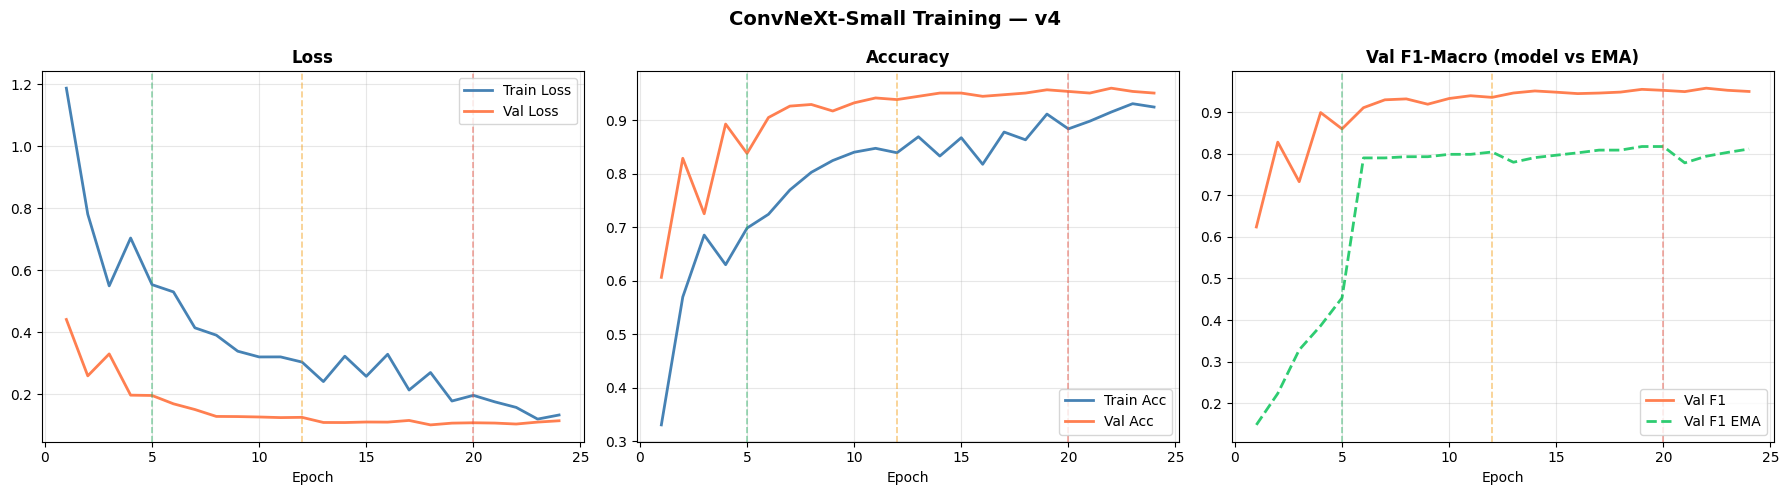


Best Val F1 (model) : 0.9580
Best Val F1 (EMA)   : 0.8176
EMA gain            : +-0.1404


In [ ]:
ep_range = range(1, len(history['va_f1'])+1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ConvNeXt-Small Training — v4', fontsize=14, fontweight='bold')

# Stage boundary lines
boundaries = np.cumsum([e for _,e,*_ in PROG_STAGES])
bc = ['#27ae60','#f39c12','#e74c3c','#9b59b6']

# Loss
axes[0].plot(ep_range, history['tr_loss'], label='Train Loss', color='steelblue', lw=2)
axes[0].plot(ep_range, history['va_loss'], label='Val Loss',   color='coral',     lw=2)
axes[0].set_title('Loss', fontweight='bold')

# Accuracy
axes[1].plot(ep_range, history['tr_acc'], label='Train Acc', color='steelblue', lw=2)
axes[1].plot(ep_range, history['va_acc'], label='Val Acc',   color='coral',     lw=2)
axes[1].set_title('Accuracy', fontweight='bold')

# F1 — model vs EMA
axes[2].plot(ep_range, history['va_f1'],     label='Val F1',     color='coral',   lw=2)
axes[2].plot(ep_range, history['va_f1_ema'], label='Val F1 EMA', color='#2ecc71', lw=2, ls='--')
axes[2].set_title('Val F1-Macro (model vs EMA)', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
    for b, c in zip(boundaries[:-1], bc):
        if b < len(ep_range):
            ax.axvline(x=b, color=c, ls='--', alpha=0.5, lw=1.2)

plt.tight_layout()
plt.savefig('training_history_v4.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
best_f1     = max(history['va_f1'])
best_f1_ema = max(history['va_f1_ema'])
print(f'\nBest Val F1 (model) : {best_f1:.4f}')
print(f'Best Val F1 (EMA)   : {best_f1_ema:.4f}')
print(f'EMA gain            : +{best_f1_ema - best_f1:.4f}')

## 13. Evaluasi — Model vs EMA

In [ ]:
# Muat dua checkpoint
ckpt_m = torch.load(CKPT_PATH, map_location=DEVICE)
ckpt_e = torch.load(CKPT_EMA,  map_location=DEVICE)
print(f'Model  best: epoch={ckpt_m["epoch"]} stage={ckpt_m["stage"]} F1={ckpt_m["best_val_f1"]:.4f}')
print(f'EMA    best: epoch={ckpt_e["epoch"]} stage={ckpt_e["stage"]} F1={ckpt_e["best_val_f1"]:.4f}')

val_ds  = FaceDataset(val_samples, transform=get_val_transform(224))
val_ldr = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


def full_evaluate(state_dict, loader, label='Model'):
    model.load_state_dict(state_dict)
    model.eval()
    all_p, all_l, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f'Eval {label}', leave=False):
            probs = torch.softmax(model(imgs.to(DEVICE)), 1)
            all_probs.append(probs.cpu().numpy())
            all_p.extend(probs.argmax(1).cpu().numpy())
            all_l.extend(labels.numpy())
    probs_arr = np.concatenate(all_probs)
    f1  = f1_score(all_l, all_p, average='macro', zero_division=0)
    acc = accuracy_score(all_l, all_p)
    return all_l, all_p, probs_arr, f1, acc


gt, preds_m, probs_m, f1_m, acc_m = full_evaluate(ckpt_m['model_state_dict'], val_ldr, 'Model')
gt, preds_e, probs_e, f1_e, acc_e = full_evaluate(ckpt_e['model_state_dict'], val_ldr, 'EMA')

print(f'\n{"="*55}')
print(f'  Standard model : Acc={acc_m:.4f}  F1={f1_m:.4f}')
print(f'  EMA model      : Acc={acc_e:.4f}  F1={f1_e:.4f}')
print(f'  EMA gain       : +{f1_e - f1_m:.4f} F1  +{acc_e - acc_m:.4f} Acc')
print(f'{"="*55}')

# Pilih yang terbaik untuk inference
BEST_CKPT  = CKPT_EMA  if f1_e >= f1_m else CKPT_PATH
best_state = ckpt_e['model_state_dict'] if f1_e >= f1_m else ckpt_m['model_state_dict']
print(f'\n→ Akan pakai: {"EMA" if f1_e >= f1_m else "Standard"} weights untuk submission')
model.load_state_dict(best_state)

Model  best: epoch=22 stage=4 F1=0.9580
EMA    best: epoch=19 stage=3 F1=0.8176


Eval Model:   0%|          | 0/11 [00:00<?, ?it/s]

Eval EMA:   0%|          | 0/11 [00:00<?, ?it/s]


  Standard model : Acc=0.9512  F1=0.9503
  EMA model      : Acc=0.7927  F1=0.8176
  EMA gain       : +-0.1328 F1  +-0.1585 Acc

→ Akan pakai: Standard weights untuk submission


<All keys matched successfully>


📋 Classification Report (best model)
                precision    recall  f1-score   support

    realperson     0.9438    0.9333    0.9385        90
  fake_printed     0.9630    0.9286    0.9455        28
   fake_screen     0.9302    1.0000    0.9639        40
     fake_mask     0.9091    0.9259    0.9174        54
fake_mannequin     0.9545    0.9333    0.9438        45
  fake_unknown     1.0000    0.9859    0.9929        71

      accuracy                         0.9512       328
     macro avg     0.9501    0.9512    0.9503       328
  weighted avg     0.9517    0.9512    0.9512       328



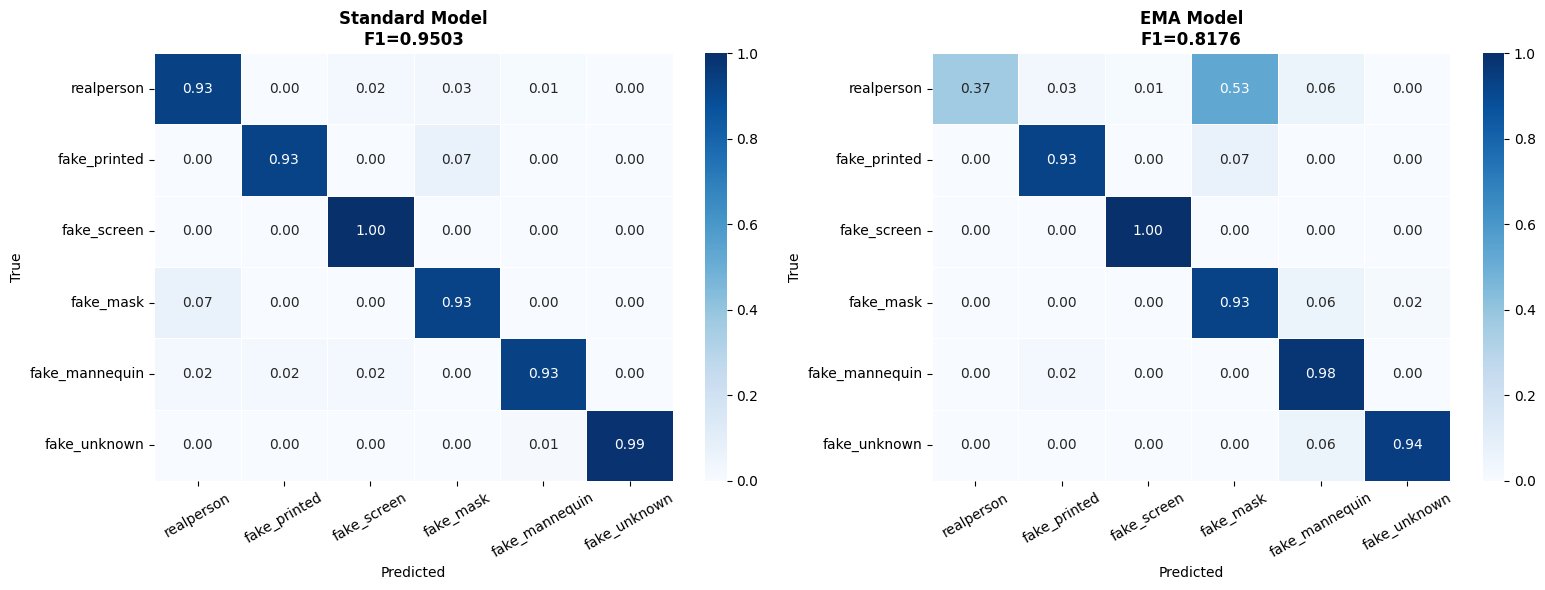

In [ ]:
# Classification Report
best_preds = preds_e if f1_e >= f1_m else preds_m
print('\n📋 Classification Report (best model)')
print('='*60)
print(classification_report(gt, best_preds, target_names=CLASS_NAMES, digits=4))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (title, preds_) in zip(axes, [('Standard Model', preds_m), ('EMA Model', preds_e)]):
    cm = confusion_matrix(gt, preds_).astype(float)
    cm /= cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt='.2f',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', ax=ax, linewidths=0.5)
    f1_ = f1_score(gt, preds_, average='macro', zero_division=0)
    ax.set_title(f'{title}\nF1={f1_:.4f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('confusion_matrix_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Inference Test Set + Submission

In [ ]:
def predict_tta(model, test_dir, tta_transforms, device):
    """5-pass TTA inference."""
    model.eval()
    avg_probs = None
    all_ids   = None

    for t_idx, tfm in enumerate(tta_transforms):
        ds     = TestDataset(test_dir, transform=tfm)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
        print(f'  TTA {t_idx+1}/{len(tta_transforms)}...')

        probs_list, ids_list = [], []
        with torch.no_grad():
            for imgs, ids in tqdm(loader, leave=False):
                probs = torch.softmax(model(imgs.to(device)), 1).cpu().numpy()
                probs_list.append(probs)
                ids_list.extend(ids)

        p_arr = np.concatenate(probs_list)
        avg_probs = p_arr if avg_probs is None else avg_probs + p_arr
        all_ids   = ids_list

    avg_probs  /= len(tta_transforms)
    pred_labels = [IDX2CLASS[i] for i in avg_probs.argmax(1)]
    return all_ids, pred_labels, avg_probs


print('🔍 TTA Inference (5 passes)...')
tta_tfms = get_tta_transforms(img_size=224)
test_ids, test_preds, test_probs = predict_tta(model, TEST_DIR, tta_tfms, DEVICE)
print(f'\n✅ {len(test_ids)} sampel diprediksi')

# Generate CSV
submission_df = pd.DataFrame({'id': test_ids, 'label': test_preds})
submission_df = submission_df.sort_values('id').reset_index(drop=True)
submission_df.to_csv(OUTPUT_CSV, index=False)

print(f'\n✅ Saved → {OUTPUT_CSV}')
print(submission_df.head(6).to_string(index=False))

🔍 TTA Inference (5 passes)...
  TTA 1/5...


  0%|          | 0/13 [00:00<?, ?it/s]

  TTA 2/5...


  0%|          | 0/13 [00:00<?, ?it/s]

  TTA 3/5...


...

  TTA 4/5...


  0%|          | 0/13 [00:00<?, ?it/s]

  TTA 5/5...


  0%|          | 0/13 [00:00<?, ?it/s]


✅ 404 sampel diprediksi

✅ Saved → submission_v4.csv
      id          label
test_001    fake_screen
test_002 fake_mannequin
test_003      fake_mask
test_004     realperson
test_005   fake_printed
test_006 fake_mannequin


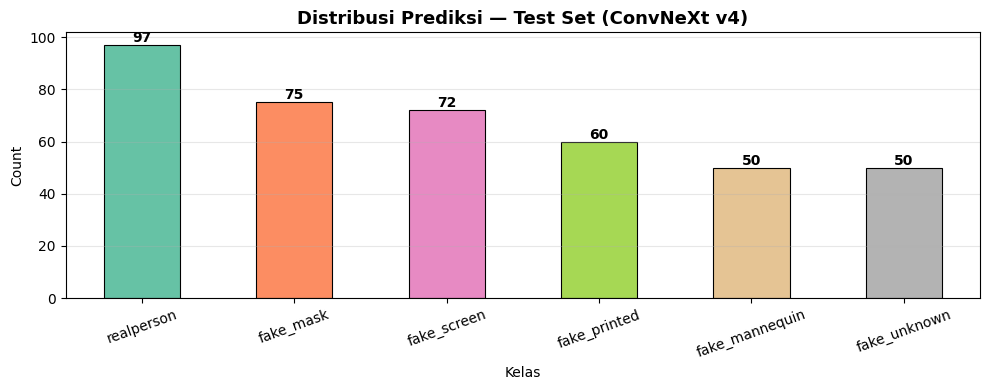

  Rows   : 404
  Nulls  : 0
  Invalid: 0
  Labels : ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']

  📁 Siap: submission_v4.csv


In [ ]:
# Distribusi & verifikasi
fig, ax = plt.subplots(figsize=(10, 4))
vc = submission_df['label'].value_counts()
vc.plot(kind='bar', ax=ax, color=plt.cm.Set2(np.linspace(0,1,len(vc))),
        edgecolor='black', linewidth=0.8)
ax.set_title('Distribusi Prediksi — Test Set (ConvNeXt v4)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kelas'); ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
ax.tick_params(axis='x', rotation=20); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print('='*55)
invalid = submission_df[~submission_df['label'].isin(set(CLASS_NAMES))]
print(f'  Rows   : {len(submission_df)}')
print(f'  Nulls  : {submission_df.isnull().sum().sum()}')
print(f'  Invalid: {len(invalid)}')
print(f'  Labels : {sorted(submission_df["label"].unique())}')
print(f'\n  📁 Siap: {OUTPUT_CSV}')

---
## 📋 Summary v4 — ConvNeXt-Small

### Kenapa ConvNeXt lebih baik dari ResNet50/EfficientNetV2 untuk kasus ini?

**1. ImageNet-21k pretrained** — dilatih di 21k kelas bukan 1k → fitur jauh lebih kaya dan beragam

**2. 7×7 depthwise conv** — ConvNeXt pakai kernel 7×7 (vs 3×3 ResNet). Receptive field lebih besar per layer → lebih sensitif ke **pola tekstur** (moiré, serat, grain) yang justru kunci deteksi spoofing

**3. LayerNorm > BatchNorm** — BatchNorm bergantung pada statistik batch (buruk untuk batch kecil), LayerNorm lebih stabil

**4. Inverted bottleneck + GELU** — arsitektur lebih modern, lebih cocok kombinasi dengan fine-tuning

**5. EMA weights** — untuk dataset 1600, tiap batch update bisa sangat noisy. EMA menghaluskan sehingga model akhir lebih robust

| Teknik | Deskripsi |
|---|---|
| ConvNeXt-Small (IN21k) | Backbone utama |
| GAP + GMP + GeM | Triple pooling |
| RandAugment (m9) | Policy-based augmentasi |
| Mixup + CutMix | Online batch mixing |
| Focal Loss + adaptive LS | Handle imbalance |
| SAM + AdamW | Flat minima optimizer |
| OneCycleLR per stage | Optimal LR schedule |
| Layer-wise LR decay | Backbone fine-tune |
| EMA (decay=0.9998) | Weight smoothing |
| Progressive resize 128→256 | Curriculum learning |
| 5-pass TTA | Inference robustness |